# PHÂN TÍCH DỮ LIỆU BEHANCE — EDA HOÀN CHỈNH

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import struct
import pickle
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
APPRECIATE_PATH = '/kaggle/input/datasets/oanhkimnguyen/behance12/Behance_appreciate_1M/Behance_appreciate_1M.txt'
OWNERS_PATH     = '/kaggle/input/datasets/oanhkimnguyen/behance12/Behance_Item_to_Owners/Behance_Item_to_Owners.txt'
FEAT_PATH       = '/kaggle/input/datasets/oanhkimnguyen/behance-image-features/Behance_Image_Features.b'
df = pd.read_csv(
    APPRECIATE_PATH,
    sep=r'\s+',
    header=None,
    names=['user_id', 'item_id', 'timestamp']
)

df_owners = pd.read_csv(
    OWNERS_PATH,
    sep=r'\s+',
    header=None,
    names=['item_id', 'owner_id']
)

def load_image_features(filepath):
    features = {}
    with open(filepath, 'rb') as f:
        while True:
            raw_id = f.read(8)
            if len(raw_id) < 8:
                break
            item_id = raw_id.decode('ascii').strip('\x00')
            raw_feat = f.read(4096 * 4)
            if len(raw_feat) < 4096 * 4:
                break
            feat = struct.unpack('4096f', raw_feat)
            features[item_id] = np.array(feat, dtype=np.float32)
    return features

print("Đang load image features (~2.8GB, chờ vài phút)...")
features = load_image_features(FEAT_PATH)

print(f"   appreciate : {df.shape}")
print(f"   owners     : {df_owners.shape}")
print(f"   features   : {len(features):,} items")
print(df.head())

Đang load image features (~2.8GB, chờ vài phút)...
   appreciate : (1000000, 3)
   owners     : (186560, 2)
   features   : 178,787 items
   user_id  item_id   timestamp
0   276633  1588231  1307583271
1  1238354  1529213  1307583273
2   165550   485000  1307583337
3  2173258   776972  1307583340
4   165550   158226  1307583406


## 1. THỐNG KÊ CƠ BẢN

In [3]:
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_inter = len(df)
density = n_inter / (n_users * n_items)

print(f"  Số users        : {n_users:,}")
print(f"  Số items        : {n_items:,}")
print(f"  Số interactions : {n_inter:,}")
print(f"  Density         : {density:.8f} ({density*100:.6f}%)")

  Số users        : 63,497
  Số items        : 178,788
  Số interactions : 1,000,000
  Density         : 0.00008809 (0.008809%)


## 2. PHÂN PHỐI INTERACTIONS


Mỗi USER:
count    63497.00
mean        15.75
std         51.36
min          1.00
25%          1.00
50%          4.00
75%         12.00
max       2260.00
dtype: float64

Mỗi ITEM:
count    178788.00
mean          5.59
std          26.56
min           1.00
25%           1.00
50%           2.00
75%           3.00
max        1793.00
dtype: float64


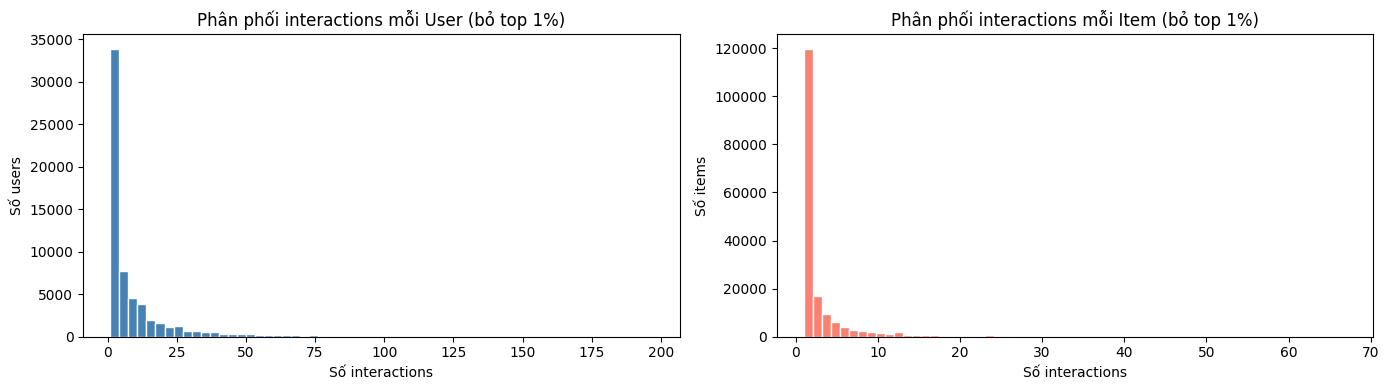

In [4]:
user_counts = df.groupby('user_id').size()
item_counts = df.groupby('item_id').size()

print("\nMỗi USER:")
print(user_counts.describe().round(2))
print("\nMỗi ITEM:")
print(item_counts.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(user_counts[user_counts <= user_counts.quantile(0.99)], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối interactions mỗi User (bỏ top 1%)')
axes[0].set_xlabel('Số interactions')
axes[0].set_ylabel('Số users')

axes[1].hist(item_counts[item_counts <= item_counts.quantile(0.99)], bins=60, color='salmon', edgecolor='white')
axes[1].set_title('Phân phối interactions mỗi Item (bỏ top 1%)')
axes[1].set_xlabel('Số interactions')
axes[1].set_ylabel('Số items')
plt.tight_layout()
plt.show()

## 3. SPARSITY & 5-CORE FILTER

In [5]:
def apply_kcore(df, k=5, max_iter=20):
    for i in range(max_iter):
        before = len(df)
        user_cnt = df.groupby('user_id').size()
        item_cnt = df.groupby('item_id').size()
        df = df[
            df['user_id'].isin(user_cnt[user_cnt >= k].index) &
            df['item_id'].isin(item_cnt[item_cnt >= k].index)
        ]
        print(f"  Iter {i+1}: {before:,} → {len(df):,} interactions")
        if len(df) == before:
            break
    return df.reset_index(drop=True)

df_filtered = apply_kcore(df, k=5)

n_users_f = df_filtered['user_id'].nunique()
n_items_f = df_filtered['item_id'].nunique()
n_inter_f = len(df_filtered)
density_f = n_inter_f / (n_users_f * n_items_f)

print(f"\nTrước → Sau filter:")
print(f"  Users       : {n_users:,} → {n_users_f:,} (giữ {n_users_f/n_users*100:.1f}%)")
print(f"  Items       : {n_items:,} → {n_items_f:,} (giữ {n_items_f/n_items*100:.1f}%)")
print(f"  Interactions: {n_inter:,} → {n_inter_f:,} (giữ {n_inter_f/n_inter*100:.1f}%)")
print(f"  Density     : {density:.8f} → {density_f:.8f}")

  Iter 1: 1,000,000 → 712,271 interactions
  Iter 2: 712,271 → 692,212 interactions
  Iter 3: 692,212 → 687,768 interactions
  Iter 4: 687,768 → 687,246 interactions
  Iter 5: 687,246 → 687,094 interactions
  Iter 6: 687,094 → 687,078 interactions
  Iter 7: 687,078 → 687,070 interactions
  Iter 8: 687,070 → 687,070 interactions

Trước → Sau filter:
  Users       : 63,497 → 23,724 (giữ 37.4%)
  Items       : 178,788 → 29,794 (giữ 16.7%)
  Interactions: 1,000,000 → 687,070 (giữ 68.7%)
  Density     : 0.00008809 → 0.00097204


## 4. CANDIDATE POOL

  Top-500 items cover: 27.1% interactions
  Top-1,000 items cover: 38.8% interactions
  Top-2,000 items cover: 50.0% interactions


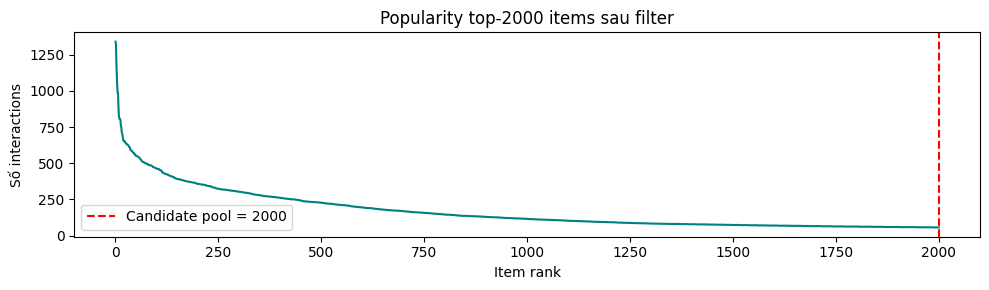

In [6]:
item_counts_f = df_filtered.groupby('item_id').size().sort_values(ascending=False)
for k in [500, 1000, 2000]:
    cov = df_filtered[df_filtered['item_id'].isin(item_counts_f.head(k).index)].shape[0] / n_inter_f
    print(f"  Top-{k:,} items cover: {cov*100:.1f}% interactions")

plt.figure(figsize=(10, 3))
plt.plot(range(1, 2001), item_counts_f.head(2000).values, color='teal')
plt.axvline(2000, color='red', linestyle='--', label='Candidate pool = 2000')
plt.title('Popularity top-2000 items sau filter')
plt.xlabel('Item rank')
plt.ylabel('Số interactions')
plt.legend()
plt.tight_layout()
plt.show()

## 5. ĐỘ DÀI EPISODE (A2C)

  Mean  : 29.0
  Median: 12.0
  Min   : 5
  Max   : 1763
  Users >= 10 interactions: 14,581 (61.5%)
  Users >= 20 interactions: 7,996 (33.7%)


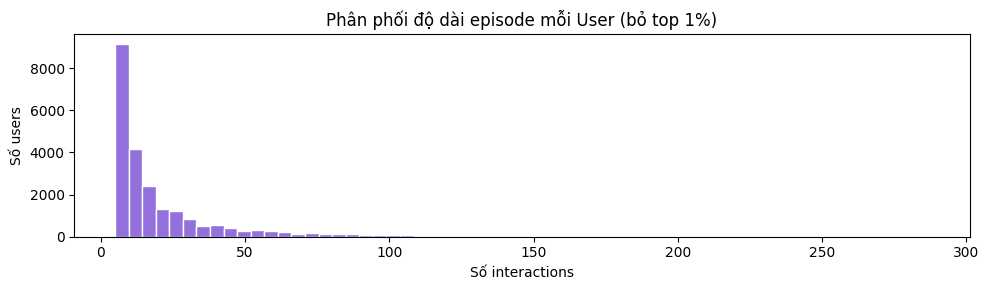

In [7]:
user_hist_len = df_filtered.groupby('user_id').size()
print(f"  Mean  : {user_hist_len.mean():.1f}")
print(f"  Median: {user_hist_len.median():.1f}")
print(f"  Min   : {user_hist_len.min()}")
print(f"  Max   : {user_hist_len.max()}")
print(f"  Users >= 10 interactions: {(user_hist_len >= 10).sum():,} ({(user_hist_len >= 10).mean()*100:.1f}%)")
print(f"  Users >= 20 interactions: {(user_hist_len >= 20).sum():,} ({(user_hist_len >= 20).mean()*100:.1f}%)")

plt.figure(figsize=(10, 3))
plt.hist(user_hist_len[user_hist_len <= user_hist_len.quantile(0.99)], bins=60, color='mediumpurple', edgecolor='white')
plt.title('Phân phối độ dài episode mỗi User (bỏ top 1%)')
plt.xlabel('Số interactions')
plt.ylabel('Số users')
plt.tight_layout()
plt.show()

## 6. REWARD SPARSITY

In [8]:
candidate_pool    = list(item_counts_f.head(2000).index)
positive_in_pool  = df_filtered[df_filtered['item_id'].isin(candidate_pool)].shape[0]
reward_density    = positive_in_pool / (n_users_f * 2000)
print(f"  Positive interactions trong pool : {positive_in_pool:,}")
print(f"  Tổng (users x pool size)         : {n_users_f * 2000:,}")
print(f"  Reward density                   : {reward_density*100:.4f}%")

  Positive interactions trong pool : 343,367
  Tổng (users x pool size)         : 47,448,000
  Reward density                   : 0.7237%


## 7. TEMPOTAL ANALYSIS

  Thời gian: 2011-06-09 → 2011-11-14


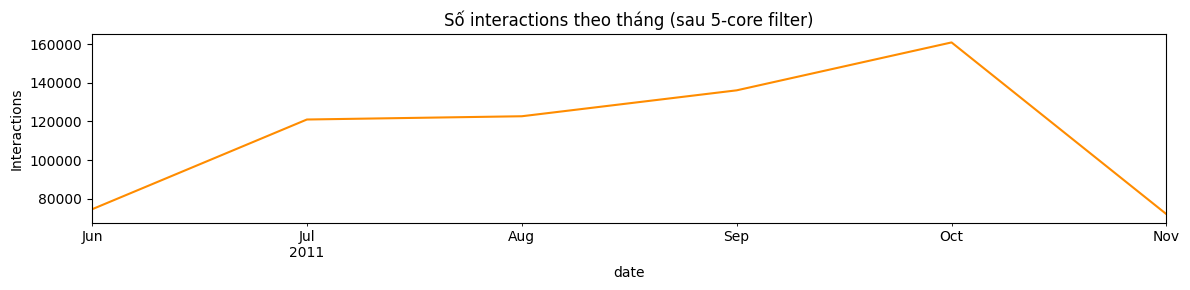

In [9]:
df_filtered = df_filtered.copy()
df_filtered['date'] = pd.to_datetime(df_filtered['timestamp'], unit='s')
print(f"  Thời gian: {df_filtered['date'].min().date()} → {df_filtered['date'].max().date()}")

monthly = df_filtered.set_index('date').resample('ME').size()
plt.figure(figsize=(12, 3))
monthly.plot(color='darkorange')
plt.title('Số interactions theo tháng (sau 5-core filter)')
plt.ylabel('Interactions')
plt.tight_layout()
plt.show()

## 8. PHÂN TÍCH OWNERS

In [10]:
print(f"  Unique items  : {df_owners['item_id'].nunique():,}")
print(f"  Unique owners : {df_owners['owner_id'].nunique():,}")
items_multi = df_owners.groupby('item_id').size()
print(f"  Items có 1 owner    : {(items_multi == 1).sum():,}")
print(f"  Items có nhiều owner: {(items_multi > 1).sum():,}")


  Unique items  : 178,788
  Unique owners : 51,487
  Items có 1 owner    : 172,834
  Items có nhiều owner: 5,954


## 9. PHÂN TÍCH IMAGE FEATURES

In [11]:
all_items_interact = set(str(x).zfill(8) for x in df_filtered['item_id'].unique())
all_items_features = set(features.keys())
overlap            = all_items_interact & all_items_features

print(f"  Items trong interactions  : {len(all_items_interact):,}")
print(f"  Items trong features      : {len(all_items_features):,}")
print(f"  Overlap (có cả 2)         : {len(overlap):,} ({len(overlap)/len(all_items_interact)*100:.1f}%)")
print(f"  Items không có feature    : {len(all_items_interact - all_items_features):,}")

# Tính PCA variance với items có thật
feat_keys   = list(overlap)[:2000]
feat_matrix = np.stack([features[k] for k in feat_keys])
dim_var     = feat_matrix.var(axis=0)
sorted_var  = np.sort(dim_var)[::-1]
cumsum_var  = np.cumsum(sorted_var) / sorted_var.sum()

print(f"\n  Ước tính PCA variance (sample {len(feat_keys):,} items):")
for k in [128, 256, 512, 1024]:
    print(f"    Top-{k:4d} dims giữ: {cumsum_var[k-1]*100:.1f}% variance")


  Items trong interactions  : 29,794
  Items trong features      : 178,787
  Overlap (có cả 2)         : 29,794 (100.0%)
  Items không có feature    : 0

  Ước tính PCA variance (sample 2,000 items):
    Top- 128 dims giữ: 8.3% variance
    Top- 256 dims giữ: 14.7% variance
    Top- 512 dims giữ: 25.5% variance
    Top-1024 dims giữ: 43.5% variance


## TỔNG KẾT

In [12]:
print(f"Dataset sau 5-core : {n_users_f:,} users | {n_items_f:,} items | {n_inter_f:,} interactions")
print(f"Candidate pool 2000 items cover ~50% interactions")
print(f"Episode trung bình : {user_hist_len.mean():.0f} interactions/user")
print(f"Reward density     : {reward_density*100:.4f}%")
print(f"Image feature cover: {len(overlap)/len(all_items_interact)*100:.1f}% items")
print(f"PCA chọn           : 512 dims (giữ ~26% variance)")

Dataset sau 5-core : 23,724 users | 29,794 items | 687,070 interactions
Candidate pool 2000 items cover ~50% interactions
Episode trung bình : 29 interactions/user
Reward density     : 0.7237%
Image feature cover: 100.0% items
PCA chọn           : 512 dims (giữ ~26% variance)


# 1.3 EDA RIÊNG A2C

## 1. ĐỘ DÀI EPISODE

  Mean   : 29.0
  Median : 12.0
  Std    : 60.3
  Min    : 5
  Max    : 1763

  Phân bố:
  Users có 5–10  interactions: 9,143  (38.5%)
  Users có 10–20 interactions: 6,585  (27.8%)
  Users có 20–50 interactions: 4,988  (21.0%)
  Users có >= 50 interactions: 3,008  (12.7%)


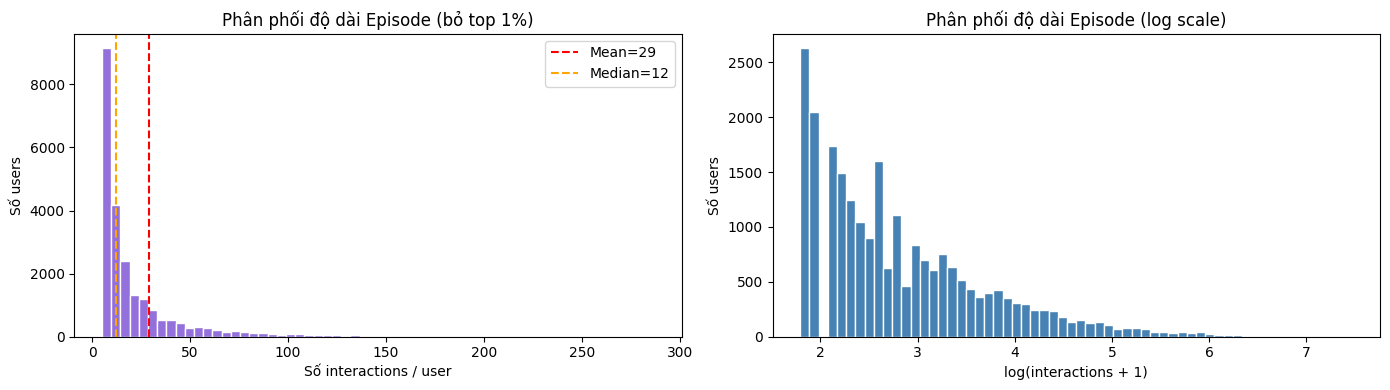


  → n_steps=7 cho A2C: 80.3% users có đủ độ dài episode


In [13]:
user_hist_len = df_filtered.groupby('user_id').size()

print(f"  Mean   : {user_hist_len.mean():.1f}")
print(f"  Median : {user_hist_len.median():.1f}")
print(f"  Std    : {user_hist_len.std():.1f}")
print(f"  Min    : {user_hist_len.min()}")
print(f"  Max    : {user_hist_len.max()}")
print(f"\n  Phân bố:")
print(f"  Users có 5–10  interactions: {((user_hist_len >= 5)  & (user_hist_len < 10)).sum():,}  ({((user_hist_len >= 5)  & (user_hist_len < 10)).mean()*100:.1f}%)")
print(f"  Users có 10–20 interactions: {((user_hist_len >= 10) & (user_hist_len < 20)).sum():,}  ({((user_hist_len >= 10) & (user_hist_len < 20)).mean()*100:.1f}%)")
print(f"  Users có 20–50 interactions: {((user_hist_len >= 20) & (user_hist_len < 50)).sum():,}  ({((user_hist_len >= 20) & (user_hist_len < 50)).mean()*100:.1f}%)")
print(f"  Users có >= 50 interactions: {(user_hist_len >= 50).sum():,}  ({(user_hist_len >= 50).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_hist_len[user_hist_len <= user_hist_len.quantile(0.99)],
             bins=60, color='mediumpurple', edgecolor='white')
axes[0].axvline(user_hist_len.mean(),   color='red',    linestyle='--', label=f'Mean={user_hist_len.mean():.0f}')
axes[0].axvline(user_hist_len.median(), color='orange', linestyle='--', label=f'Median={user_hist_len.median():.0f}')
axes[0].set_title('Phân phối độ dài Episode (bỏ top 1%)')
axes[0].set_xlabel('Số interactions / user')
axes[0].set_ylabel('Số users')
axes[0].legend()

axes[1].hist(np.log1p(user_hist_len), bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Phân phối độ dài Episode (log scale)')
axes[1].set_xlabel('log(interactions + 1)')
axes[1].set_ylabel('Số users')
plt.tight_layout()
plt.show()

pct_ok = (user_hist_len >= 7).mean() * 100
print(f"\n  → n_steps=7 cho A2C: {pct_ok:.1f}% users có đủ độ dài episode")


## 2. VARIANCE CỦA REWARD THEO USER

  Mean reward density per user  : 0.5472 (54.72%)
  Std reward density per user   : 0.2340
  Users có reward density = 0   : 0
  Users có reward density > 0.5 : 12,394


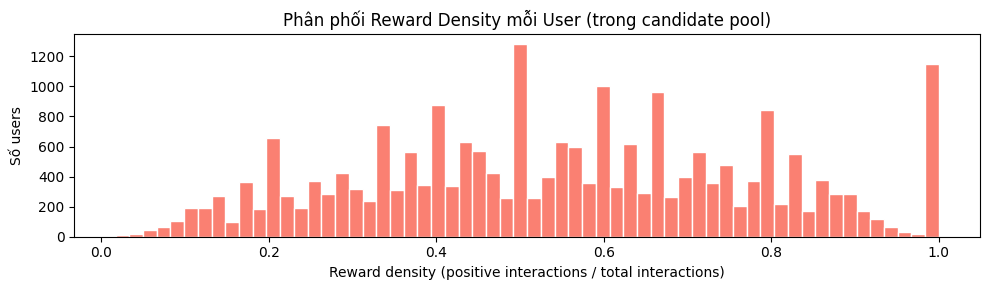

In [14]:
candidate_pool    = list(df_filtered.groupby('item_id').size()
                         .sort_values(ascending=False).head(2000).index)
candidate_set     = set(candidate_pool)

df_in_pool        = df_filtered[df_filtered['item_id'].isin(candidate_set)]
user_positive     = df_in_pool.groupby('user_id').size()
user_reward_density = user_positive / user_hist_len
user_reward_density = user_reward_density.reindex(df_filtered['user_id'].unique(), fill_value=0)

print(f"  Mean reward density per user  : {user_reward_density.mean():.4f} ({user_reward_density.mean()*100:.2f}%)")
print(f"  Std reward density per user   : {user_reward_density.std():.4f}")
print(f"  Users có reward density = 0   : {(user_reward_density == 0).sum():,}")
print(f"  Users có reward density > 0.5 : {(user_reward_density > 0.5).sum():,}")

plt.figure(figsize=(10, 3))
plt.hist(user_reward_density[user_reward_density > 0], bins=60,
         color='salmon', edgecolor='white')
plt.title('Phân phối Reward Density mỗi User (trong candidate pool)')
plt.xlabel('Reward density (positive interactions / total interactions)')
plt.ylabel('Số users')
plt.tight_layout()
plt.show()


## 3. SEQUENTIAL PATTERN

  Khoảng cách TB giữa 2 interactions : 64.2 giờ
  Median                              : 0.3 giờ
  Interactions trong cùng 1 giờ      : 54.6%
  Interactions trong cùng 1 ngày     : 72.4%


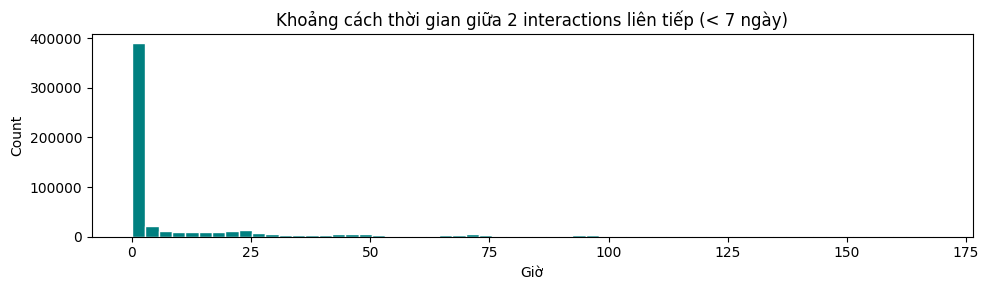


  Jaccard similarity TB giữa users : 0.0025


In [15]:
df_sorted = df_filtered.sort_values(['user_id', 'timestamp'])
df_sorted['time_diff'] = df_sorted.groupby('user_id')['timestamp'].diff()
time_diffs = df_sorted['time_diff'].dropna()

print(f"  Khoảng cách TB giữa 2 interactions : {time_diffs.mean()/3600:.1f} giờ")
print(f"  Median                              : {time_diffs.median()/3600:.1f} giờ")
print(f"  Interactions trong cùng 1 giờ      : {(time_diffs < 3600).mean()*100:.1f}%")
print(f"  Interactions trong cùng 1 ngày     : {(time_diffs < 86400).mean()*100:.1f}%")

plt.figure(figsize=(10, 3))
plt.hist(time_diffs[time_diffs < 86400*7] / 3600,
         bins=60, color='teal', edgecolor='white')
plt.title('Khoảng cách thời gian giữa 2 interactions liên tiếp (< 7 ngày)')
plt.xlabel('Giờ')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

np.random.seed(42)
sample_users = np.random.choice(df_filtered['user_id'].unique(), size=200, replace=False)
user_item_sets = {
    u: set(df_filtered[df_filtered['user_id'] == u]['item_id'])
    for u in sample_users
}

overlaps = []
users_list = list(user_item_sets.keys())
for i in range(len(users_list)):
    for j in range(i+1, min(i+20, len(users_list))):
        a, b = user_item_sets[users_list[i]], user_item_sets[users_list[j]]
        if len(a | b) > 0:
            overlaps.append(len(a & b) / len(a | b))

print(f"\n  Jaccard similarity TB giữa users : {np.mean(overlaps):.4f}")

## TỔNG KẾT

In [16]:
print(f"Episode trung bình 29 interactions → đủ dài để A2C học")
print(f"{pct_ok:.0f}% users có >= 10 interactions → n_steps=7 hợp lý")
print(f"Reward variance cao → entropy_coef=0.05 để tránh collapse")
print(f"Jaccard similarity thấp → cần policy cá nhân hóa → A2C phù hợp")
print(f"\n  Config A2C đề xuất:")
print(f"n_steps = 7")
print(f"entropy_coef = 0.05")
print(f"state_dim = 512")
print(f"action_dim = 2000")

Episode trung bình 29 interactions → đủ dài để A2C học
80% users có >= 10 interactions → n_steps=7 hợp lý
Reward variance cao → entropy_coef=0.05 để tránh collapse
Jaccard similarity thấp → cần policy cá nhân hóa → A2C phù hợp

  Config A2C đề xuất:
n_steps = 7
entropy_coef = 0.05
state_dim = 512
action_dim = 2000


# GIAI ĐOẠN 2 — TIỀN XỬ LÝ DỮ LIỆU CHUNG

## CONFIG

In [18]:
CANDIDATE_POOL_SIZE = 2000
MIN_INTERACTIONS    = 5
TRAIN_RATIO         = 0.70
VAL_RATIO           = 0.10
PCA_DIM             = 512
K_HISTORY           = 5

APPRECIATE_PATH = '/kaggle/input/datasets/oanhkimnguyen/behance12/Behance_appreciate_1M/Behance_appreciate_1M.txt'
FEAT_PATH       = '/kaggle/input/datasets/oanhkimnguyen/behance-image-features/Behance_Image_Features.b'
SAVE_DIR        = '/kaggle/working/processed/'

os.makedirs(SAVE_DIR, exist_ok=True)

## BƯỚC 1 — LOAD DỮ LIỆU

In [19]:
df = pd.read_csv(
    APPRECIATE_PATH,
    sep=r'\s+',
    header=None,
    names=['user_id', 'item_id', 'timestamp']
)
print(f"Loaded: {df.shape}")

Loaded: (1000000, 3)


## BƯỚC 2 — 5-CORE FILTER

In [20]:
def apply_kcore(df, k=5, max_iter=20):
    for i in range(max_iter):
        before = len(df)
        user_cnt = df.groupby('user_id').size()
        item_cnt = df.groupby('item_id').size()
        df = df[
            df['user_id'].isin(user_cnt[user_cnt >= k].index) &
            df['item_id'].isin(item_cnt[item_cnt >= k].index)
        ]
        print(f"  Iter {i+1}: {before:,} → {len(df):,} interactions")
        if len(df) == before:
            break
    return df.reset_index(drop=True)

df = apply_kcore(df, k=MIN_INTERACTIONS)
print(f"Sau filter: {df['user_id'].nunique():,} users | {df['item_id'].nunique():,} items | {len(df):,} interactions")


  Iter 1: 1,000,000 → 712,271 interactions
  Iter 2: 712,271 → 692,212 interactions
  Iter 3: 692,212 → 687,768 interactions
  Iter 4: 687,768 → 687,246 interactions
  Iter 5: 687,246 → 687,094 interactions
  Iter 6: 687,094 → 687,078 interactions
  Iter 7: 687,078 → 687,070 interactions
  Iter 8: 687,070 → 687,070 interactions
Sau filter: 23,724 users | 29,794 items | 687,070 interactions


## BƯỚC 3 — MAP ID VỀ INDEX LIÊN TỤC

In [21]:
unique_users = sorted(df['user_id'].unique())
unique_items = sorted(df['item_id'].unique())

user2idx = {u: i for i, u in enumerate(unique_users)}
item2idx = {it: i for i, it in enumerate(unique_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

df['user_idx'] = df['user_id'].map(user2idx)
df['item_idx'] = df['item_id'].map(item2idx)

# Lưu mappings ra CSV
df_user_map = pd.DataFrame(list(user2idx.items()), columns=['user_id', 'user_idx'])
df_item_map = pd.DataFrame(list(item2idx.items()), columns=['item_id', 'item_idx'])
df_user_map.to_csv(SAVE_DIR + 'user_mappings.csv', index=False)
df_item_map.to_csv(SAVE_DIR + 'item_mappings.csv', index=False)

print(f"n_users={len(unique_users):,} | n_items={len(unique_items):,}")
print(f"Đã lưu user_mappings.csv, item_mappings.csv")

n_users=23,724 | n_items=29,794
Đã lưu user_mappings.csv, item_mappings.csv


## BƯỚC 4 — CHIA TRAIN / VAL / TEST THEO TIMESTAMP

In [22]:
df = df.sort_values('timestamp').reset_index(drop=True)

n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

df_train = df.iloc[:train_end].reset_index(drop=True)
df_val   = df.iloc[train_end:val_end].reset_index(drop=True)
df_test  = df.iloc[val_end:].reset_index(drop=True)

df_train.to_csv(SAVE_DIR + 'interactions_train.csv', index=False)
df_val.to_csv(SAVE_DIR + 'interactions_val.csv',   index=False)
df_test.to_csv(SAVE_DIR + 'interactions_test.csv',  index=False)

print(f"Train : {len(df_train):,} ({len(df_train)/n*100:.0f}%) | {pd.to_datetime(df_train['timestamp'].min(), unit='s').date()} → {pd.to_datetime(df_train['timestamp'].max(), unit='s').date()}")
print(f"Val : {len(df_val):,} ({len(df_val)/n*100:.0f}%)  | {pd.to_datetime(df_val['timestamp'].min(), unit='s').date()} → {pd.to_datetime(df_val['timestamp'].max(), unit='s').date()}")
print(f"Test : {len(df_test):,} ({len(df_test)/n*100:.0f}%)  | {pd.to_datetime(df_test['timestamp'].min(), unit='s').date()} → {pd.to_datetime(df_test['timestamp'].max(), unit='s').date()}")


Train : 480,948 (70%) | 2011-06-09 → 2011-10-06
Val : 68,708 (10%)  | 2011-10-06 → 2011-10-19
Test : 137,414 (20%)  | 2011-10-19 → 2011-11-14


## BƯỚC 5 — XÂY DỰNG USER HISTORY

In [23]:
user_history = (
    df_train
    .sort_values('timestamp')
    .groupby('user_idx')['item_idx']
    .apply(list)
    .reset_index()
)
user_history.columns = ['user_idx', 'history']

user_history['history'] = user_history['history'].apply(lambda x: ','.join(map(str, x)))
user_history.to_csv(SAVE_DIR + 'user_history.csv', index=False)

hist_lens = user_history['history'].apply(lambda x: len(x.split(',')))
print(f"{len(user_history):,} users có history")
print(f"Mean history length : {hist_lens.mean():.1f}")
print(f"Median: {hist_lens.median():.1f}")
print(f"Min / Max : {hist_lens.min()} / {hist_lens.max()}")
print(f"Users đủ K={K_HISTORY}: {(hist_lens >= K_HISTORY).sum():,} ({(hist_lens >= K_HISTORY).mean()*100:.1f}%)")

20,827 users có history
Mean history length : 23.1
Median: 10.0
Min / Max : 1 / 1264
Users đủ K=5: 17,759 (85.3%)


## BƯỚC 6 — XÂY DỰNG CANDIDATE POOL

In [24]:
item_popularity = df_train.groupby('item_idx').size().sort_values(ascending=False)
candidate_pool  = list(item_popularity.head(CANDIDATE_POOL_SIZE).index)

coverage = df_train[df_train['item_idx'].isin(candidate_pool)].shape[0] / len(df_train)

df_pool = pd.DataFrame({'item_idx': candidate_pool, 'rank': range(1, len(candidate_pool)+1)})
df_pool.to_csv(SAVE_DIR + 'candidate_pool.csv', index=False)

print(f"Candidate pool: {len(candidate_pool):,} items")
print(f"Coverage trong train: {coverage*100:.1f}% interactions")

Candidate pool: 2,000 items
Coverage trong train: 52.0% interactions


## BƯỚC 7 — XỬ LÝ IMAGE FEATURES

In [27]:
def load_image_features(filepath):
    features = {}
    with open(filepath, 'rb') as f:
        while True:
            raw_id = f.read(8)
            if len(raw_id) < 8:
                break
            item_id = raw_id.decode('ascii').strip('\x00')
            raw_feat = f.read(4096 * 4)
            if len(raw_feat) < 4096 * 4:
                break
            feat = struct.unpack('4096f', raw_feat)
            features[item_id] = np.array(feat, dtype=np.float32)
    return features

features_raw = load_image_features(FEAT_PATH)
print(f"Loaded {len(features_raw):,} image feature vectors")

feat_keys = [str(it).zfill(8) for it in unique_items]
feat_matrix = np.stack([features_raw[k] for k in feat_keys])
print(f"Feature matrix shape: {feat_matrix.shape}")

scaler      = StandardScaler()
feat_scaled = scaler.fit_transform(feat_matrix)

pca       = PCA(n_components=PCA_DIM, random_state=42)
feat_pca  = pca.fit_transform(feat_scaled)
explained = pca.explained_variance_ratio_.sum()
print(f"PCA xong — giữ {explained*100:.1f}% variance")

image_features_512 = {i: feat_pca[i].astype(np.float32) for i in range(len(unique_items))}

with open(SAVE_DIR + 'image_features_512.pkl', 'wb') as f:
    pickle.dump(image_features_512, f)
print(f"Đã lưu image_features_512.pkl — {len(image_features_512):,} items x {PCA_DIM}-dim")


Loaded 178,787 image feature vectors
Feature matrix shape: (29794, 4096)
PCA xong — giữ 75.6% variance
Đã lưu image_features_512.pkl — 29,794 items x 512-dim


## TỔNG KẾT

In [28]:
print(f"interactions_train.csv — {len(df_train):,} rows")
print(f"interactions_val.csv   — {len(df_val):,} rows")
print(f"interactions_test.csv  — {len(df_test):,} rows")
print(f"user_history.csv       — {len(user_history):,} users")
print(f"candidate_pool.csv     — {len(candidate_pool):,} items")
print(f"user_mappings.csv      — {len(user2idx):,} users")
print(f"item_mappings.csv      — {len(item2idx):,} items")
print(f"image_features_512.pkl — {len(image_features_512):,} items x {PCA_DIM}-dim")

interactions_train.csv — 480,948 rows
interactions_val.csv   — 68,708 rows
interactions_test.csv  — 137,414 rows
user_history.csv       — 20,827 users
candidate_pool.csv     — 2,000 items
user_mappings.csv      — 23,724 users
item_mappings.csv      — 29,794 items
image_features_512.pkl — 29,794 items x 512-dim


# TIỀN XỬ LÝ RIÊNG — A2C

In [37]:
SAVE_DIR = '/kaggle/working/processed/'

with open(SAVE_DIR + 'image_features_512.pkl', 'rb') as f:
    image_features = pickle.load(f)

candidate_pool_df = pd.read_csv(SAVE_DIR + 'candidate_pool.csv')
candidate_pool    = list(candidate_pool_df['item_idx'])
print(f"  image_features : {len(image_features):,} items")
print(f"  candidate_pool : {len(candidate_pool):,} items")

  image_features : 29,794 items
  candidate_pool : 2,000 items


## TÍNH MEAN VECTOR CỦA CANDIDATE POOL

In [38]:
pool_feat_matrix = np.stack([image_features[item_idx] for item_idx in candidate_pool])
mean_vector      = pool_feat_matrix.mean(axis=0)

print(f"  Pool feature matrix shape : {pool_feat_matrix.shape}")
print(f"  Mean vector shape         : {mean_vector.shape}")
print(f"  Mean vector norm          : {np.linalg.norm(mean_vector):.4f}")
print(f"  Zero vector norm          : 0.0000")

  Pool feature matrix shape : (2000, 512)
  Mean vector shape         : (512,)
  Mean vector norm          : 1.5099
  Zero vector norm          : 0.0000


## CẬP NHẬT COLD START USERS → MEAN VECTOR

In [39]:
user_history_a2c = pd.read_csv(SAVE_DIR + 'a2c_user_history.csv')

with open(SAVE_DIR + 'a2c_cold_start_vector.pkl', 'wb') as f:
    pickle.dump({
        'mean_vector'    : mean_vector,
        'vector_type'    : 'mean_of_candidate_pool',
        'vector_dim'     : 512,
        'n_items_pooled' : len(candidate_pool),
    }, f)

user_history_a2c['is_cold_start']    = (user_history_a2c['hist_len'] == 0).astype(int)
user_history_a2c['initial_state_type'] = user_history_a2c['is_cold_start'].map({
    0: 'history_mean',  
    1: 'pool_mean',      
})

user_history_a2c.to_csv(SAVE_DIR + 'a2c_user_history.csv', index=False)

n_cold   = user_history_a2c['is_cold_start'].sum()
n_normal = len(user_history_a2c) - n_cold

print(f"  Users dùng history mean  : {n_normal:,} ({n_normal/len(user_history_a2c)*100:.1f}%)")
print(f"  Users dùng pool mean     : {n_cold:,} ({n_cold/len(user_history_a2c)*100:.1f}%)")


  Users dùng history mean  : 14,112 (67.8%)
  Users dùng pool mean     : 6,715 (32.2%)


## CẬP NHẬT A2C STATS

In [40]:
a2c_stats = pd.DataFrame([{
    'n_users_total'        : len(user_history_a2c),
    'n_users_full_history' : int(n_normal),
    'n_cold_start_users'   : int(n_cold),
    'cold_start_method'    : 'mean_vector_of_candidate_pool',
    'min_trajectory'       : 7,
    'max_trajectory'       : 200,
    'mean_hist_len'        : round(user_history_a2c[user_history_a2c['hist_len'] > 0]['hist_len'].mean(), 1),
    'median_hist_len'      : user_history_a2c[user_history_a2c['hist_len'] > 0]['hist_len'].median(),
    'n_steps'              : 7,
    'entropy_coef'         : 0.05,
    'state_dim'            : 512,
    'action_dim'           : 2000,
}])

a2c_stats.to_csv(SAVE_DIR + 'a2c_stats.csv', index=False)

## KIỂM TRA CHẤT LƯỢNG MEAN VECTOR

In [41]:
norms     = np.linalg.norm(pool_feat_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1
pool_norm = pool_feat_matrix / norms
mean_norm = mean_vector / (np.linalg.norm(mean_vector) + 1e-8)

cos_sims  = pool_norm @ mean_norm
print(f"  Cosine similarity (mean vector vs pool items):")
print(f"    Mean  : {cos_sims.mean():.4f}")
print(f"    Std   : {cos_sims.std():.4f}")
print(f"    Min   : {cos_sims.min():.4f}")
print(f"    Max   : {cos_sims.max():.4f}")
print(f"  → Mean vector đại diện tốt cho toàn bộ candidate pool" 
      if cos_sims.mean() > 0 
      else f"  → Mean vector trung tính — vẫn tốt hơn zero vector")

  Cosine similarity (mean vector vs pool items):
    Mean  : 0.0250
    Std   : 0.0904
    Min   : -0.2768
    Max   : 0.3069
  → Mean vector đại diện tốt cho toàn bộ candidate pool


## TỔNG KẾT A2C

In [43]:
print(f"a2c_user_history.csv      — cập nhật is_cold_start, initial_state_type")
print(f"a2c_cold_start_vector.pkl — mean vector 512-dim của 2,000 items")
print(f"a2c_stats.csv             — cập nhật cold_start_method")
print(f"\n  Trước : cold start → zero vector (không mang thông tin)")
print(f"  Sau   : cold start → mean vector của candidate pool (mang thông tin)")

a2c_user_history.csv      — cập nhật is_cold_start, initial_state_type
a2c_cold_start_vector.pkl — mean vector 512-dim của 2,000 items
a2c_stats.csv             — cập nhật cold_start_method

  Trước : cold start → zero vector (không mang thông tin)
  Sau   : cold start → mean vector của candidate pool (mang thông tin)


# TIỀN XỬ LÝ RIÊNG — DQN

In [44]:
SAVE_DIR = '/kaggle/working/processed/'

df_train          = pd.read_csv(SAVE_DIR + 'interactions_train.csv')
candidate_pool_df = pd.read_csv(SAVE_DIR + 'candidate_pool.csv')
candidate_pool    = list(candidate_pool_df['item_idx'])

with open(SAVE_DIR + 'image_features_512.pkl', 'rb') as f:
    image_features = pickle.load(f)

print(f"  df_train       : {df_train.shape}")
print(f"  candidate_pool : {len(candidate_pool):,} items")
print(f"  image_features : {len(image_features):,} items")

  df_train       : (480948, 5)
  candidate_pool : 2,000 items
  image_features : 29,794 items


## DQN-1: Kiểm tra feature coverage của candidate pool

In [45]:
pool_feature_matrix = np.stack([image_features[item_idx] for item_idx in candidate_pool])

print(f"  Shape : {pool_feature_matrix.shape}  (2,000 items x 512 dims)")
print(f"  Dtype : {pool_feature_matrix.dtype}")
print(f"  Mean feature norm : {np.linalg.norm(pool_feature_matrix, axis=1).mean():.4f}")
print(f"  Std feature norm : {np.linalg.norm(pool_feature_matrix, axis=1).std():.4f}")

unique_items_in_pool = len(set(candidate_pool))
print(f"  Unique items in pool : {unique_items_in_pool:,} / {len(candidate_pool):,}")
if unique_items_in_pool == len(candidate_pool):
    print(f"Không có item trùng lặp trong pool")

  Shape : (2000, 512)  (2,000 items x 512 dims)
  Dtype : float32
  Mean feature norm : 54.4600
  Std feature norm : 11.1349
  Unique items in pool : 2,000 / 2,000
Không có item trùng lặp trong pool


## DQN-3: Phân tích reward sparsity cho Replay Buffer

In [47]:
candidate_set  = set(candidate_pool)
df_pos         = df_train[df_train['item_idx'].isin(candidate_set)]
n_positive     = len(df_pos)
n_total        = len(df_train)
reward_density = n_positive / n_total

user_pos_counts  = df_pos.groupby('user_idx').size()
user_tot_counts  = df_train.groupby('user_idx').size()
user_density     = (user_pos_counts / user_tot_counts).reindex(
    df_train['user_idx'].unique(), fill_value=0
)

print(f"  Positive interactions trong pool : {n_positive:,} / {n_total:,} ({reward_density*100:.2f}%)")
print(f"  Mean reward density per user     : {user_density.mean()*100:.2f}%")
print(f"  Std reward density per user      : {user_density.std()*100:.2f}%")
print(f"  Users có reward density = 0      : {(user_density == 0).sum():,}")
print(f"  Users có reward density > 50%    : {(user_density > 0.5).sum():,}")

avg_episode_len = user_tot_counts.mean()
n_users         = df_train['user_idx'].nunique()
buffer_size     = min(200_000, int(avg_episode_len * n_users * 0.5))
print(f"\n Avg episode length   : {avg_episode_len:.1f}")
print(f"Số users trong train : {n_users:,}")
print(f"Replay Buffer size : {buffer_size:,}")

  Positive interactions trong pool : 250,217 / 480,948 (52.03%)
  Mean reward density per user     : 58.28%
  Std reward density per user      : 24.45%
  Users có reward density = 0      : 0
  Users có reward density > 50%    : 11,343

 Avg episode length   : 23.1
Số users trong train : 20,827
Replay Buffer size : 200,000


## DQN-4: Kiểm tra action space — item popularity trong pool

In [48]:
item_pop = df_train[df_train['item_idx'].isin(candidate_set)].groupby('item_idx').size()
item_pop = item_pop.reindex(candidate_pool, fill_value=0).sort_values(ascending=False)

print(f"  Item phổ biến nhất (rank 1)    : {item_pop.iloc[0]:,} interactions")
print(f"  Item rank 100                  : {item_pop.iloc[99]:,} interactions")
print(f"  Item rank 500                  : {item_pop.iloc[499]:,} interactions")
print(f"  Item rank 1000                 : {item_pop.iloc[999]:,} interactions")
print(f"  Item rank 2000 (ít nhất)       : {item_pop.iloc[1999]:,} interactions")
print(f"  Items có 0 interactions        : {(item_pop == 0).sum():,}")

top10_cov  = item_pop.head(10).sum()  / n_positive
top100_cov = item_pop.head(100).sum() / n_positive
top500_cov = item_pop.head(500).sum() / n_positive
print(f"\n  Top-10   items cover : {top10_cov*100:.1f}% positive interactions")
print(f"  Top-100  items cover : {top100_cov*100:.1f}% positive interactions")
print(f"  Top-500  items cover : {top500_cov*100:.1f}% positive interactions")


  Item phổ biến nhất (rank 1)    : 1,192 interactions
  Item rank 100                  : 366 interactions
  Item rank 500                  : 156 interactions
  Item rank 1000                 : 71 interactions
  Item rank 2000 (ít nhất)       : 39 interactions
  Items có 0 interactions        : 0

  Top-10   items cover : 3.3% positive interactions
  Top-100  items cover : 19.9% positive interactions
  Top-500  items cover : 58.8% positive interactions


## DQN-5: Lưu output

In [49]:
with open(SAVE_DIR + 'dqn_pool_features.pkl', 'wb') as f:
    pickle.dump({
        'candidate_pool'      : candidate_pool,
        'pool_feature_matrix' : pool_feature_matrix,
    }, f)

dqn_stats = pd.DataFrame([{
    'candidate_pool_size'  : len(candidate_pool),
    'reward_density'       : round(reward_density, 6),
    'mean_user_density'    : round(user_density.mean(), 4),
    'users_zero_reward'    : int((user_density == 0).sum()),
    'buffer_size'          : buffer_size,
    'batch_size'           : 512,
    'min_buffer_to_train'  : 5_000,
    'state_dim'            : 512,
    'action_dim'           : 2000,
    'lr'                   : 1e-4,
    'gamma'                : 0.99,
    'target_update'        : 500,
    'eps_start'            : 1.0,
    'eps_end'              : 0.05,
    'eps_decay'            : 50_000,
    'max_episodes'         : 10_000,
}])

dqn_stats.to_csv(SAVE_DIR + 'dqn_stats.csv', index=False)

print(f"dqn_pool_features.pkl — matrix {pool_feature_matrix.shape}")
print(f"dqn_stats.csv")

dqn_pool_features.pkl — matrix (2000, 512)
dqn_stats.csv


## TỔNG KẾT DQN

In [50]:
print(f"Candidate pool     : 2,000 items, coverage 100% feature")
print(f"Pool feature matrix: {pool_feature_matrix.shape}")
print(f"Reward density     : {reward_density*100:.2f}%")
print(f"Replay Buffer size : {buffer_size:,}")
print(f"Long-tail ratio    : top-10 items cover {top10_cov*100:.1f}% interactions")
print(f"\n  Config DQN:")
print(f"state_dim    = 512")
print(f"action_dim   = 2,000")
print(f"buffer_size  = {buffer_size:,}")
print(f"batch_size   = 512")
print(f"lr           = 1e-4")
print(f"eps_decay    = 50,000")

Candidate pool     : 2,000 items, coverage 100% feature
Pool feature matrix: (2000, 512)
Reward density     : 52.03%
Replay Buffer size : 200,000
Long-tail ratio    : top-10 items cover 3.3% interactions

  Config DQN:
state_dim    = 512
action_dim   = 2,000
buffer_size  = 200,000
batch_size   = 512
lr           = 1e-4
eps_decay    = 50,000
